In [13]:
"""
异常点检测分析Notebook
用于分析同一工业缺陷类型的图片embedding分布，并识别脱离特征中心的异常数据
"""
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 添加项目路径
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.preprocessing import StandardScaler
import umap
from PIL import Image
import torch
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib
matplotlib.rc("font", family='AR PL UKai CN')

print("✓ 导入完成")


✓ 导入完成


In [14]:
npz_path = "../checkpoints/supcon_models/1229-2/extract_embeddings/60194-CCD1-负极.npz"
data = np.load(npz_path)
embeddings = data['embeddings']
label_names = data['label_names']
image_paths = data['image_paths']
mask_paths = data['mask_paths']

print(f"Embeddings 形状: {embeddings.shape}")
print(f"样本数量: {len(image_paths)}")
print(f"标签数量: {len(set(label_names))}")
print(f"唯一标签: {list(set(label_names))[:10]}...")  # 显示前10个标签

Embeddings 形状: (400, 128)
样本数量: 400
标签数量: 17
唯一标签: [np.str_('顶盖正面_污渍'), np.str_('极柱上塑胶_色差'), np.str_('顶盖正面_划伤'), np.str_('极柱上塑胶_破损'), np.str_('极柱正面_压伤'), np.str_('极柱正面_缺口'), np.str_('极柱_金属屑'), np.str_('顶盖正面_压伤'), np.str_('极柱正面_异物'), np.str_('极柱_金属丝')]...


In [15]:
# 确保 embeddings 是 numpy 数组
if not isinstance(embeddings, np.ndarray):
    embeddings = np.array(embeddings)

# 确保所有路径都是字符串格式
def decode_if_bytes(x):
    """如果是 bytes 类型，解码为字符串"""
    if isinstance(x, bytes):
        return x.decode('utf-8')
    return str(x)

# 转换路径格式
image_paths = [decode_if_bytes(p) for p in image_paths]
mask_paths = [decode_if_bytes(p) for p in mask_paths]
label_names = [decode_if_bytes(l) for l in label_names]

# 验证数据一致性
assert len(image_paths) == len(mask_paths) == len(label_names) == len(embeddings), \
    f"数据长度不一致: images={len(image_paths)}, masks={len(mask_paths)}, labels={len(label_names)}, embeddings={len(embeddings)}"

print(f"✓ 数据预处理完成")
print(f"  - 样本数: {len(image_paths)}")
print(f"  - Embedding 维度: {embeddings.shape[1]}")
print(f"  - 唯一标签数: {len(set(label_names))}")

✓ 数据预处理完成
  - 样本数: 400
  - Embedding 维度: 128
  - 唯一标签数: 17


In [16]:
unique_labels = list(set(label_names))
sorted(unique_labels)
print(f"Total unique labels: {len(unique_labels)}")
print(f"unique_labels: {unique_labels}")

selected_embeddings = []
selected_labels = []
for emb, lb in zip(embeddings, label_names):
    # if lb.startswith("capsule"):
    selected_embeddings.append(emb)
    selected_labels.append(lb)

selected_embeddings = np.stack(selected_embeddings)
print(f"selected_embeddings shape: {selected_embeddings.shape}")
print(f"selected_labels: {set(selected_labels)}")

Total unique labels: 17
unique_labels: ['顶盖正面_污渍', '极柱上塑胶_色差', '顶盖正面_划伤', '极柱上塑胶_破损', '极柱正面_压伤', '极柱正面_缺口', '极柱_金属屑', '顶盖正面_压伤', '极柱正面_异物', '极柱_金属丝', '极柱正面_磨花', '极柱正面_污渍', '顶盖正面_磨花', '顶盖四边_碰伤', '极柱正面_笔迹', '顶盖正面_笔迹', '极柱正面_划伤']
selected_embeddings shape: (400, 128)
selected_labels: {'顶盖正面_污渍', '极柱上塑胶_色差', '顶盖正面_划伤', '极柱上塑胶_破损', '极柱正面_压伤', '极柱正面_缺口', '极柱_金属屑', '顶盖正面_压伤', '极柱正面_异物', '极柱_金属丝', '极柱正面_磨花', '极柱正面_污渍', '顶盖正面_磨花', '顶盖四边_碰伤', '极柱正面_笔迹', '顶盖正面_笔迹', '极柱正面_划伤'}


In [17]:
class OutlierDetector:
    """异常点检测器 - 基于embedding分布检测异常点"""
    
    def __init__(self, embeddings: np.ndarray):
        """
        Args:
            embeddings: (N, D) embedding向量
        """
        self.embeddings = embeddings
        self.n_samples, self.n_features = embeddings.shape
        
        # 计算中心点
        self.center = np.mean(embeddings, axis=0)
        
        # 计算协方差矩阵（用于马氏距离）
        self.cov = np.cov(embeddings.T)
        # 添加正则化防止奇异
        self.cov += np.eye(self.cov.shape[0]) * 1e-6
        try:
            self.cov_inv = np.linalg.inv(self.cov)
        except:
            # 如果仍然奇异，使用伪逆
            self.cov_inv = np.linalg.pinv(self.cov)
    
    def detect_by_distance(self, threshold_percentile: float = 95.0):
        """
        基于到中心的欧氏距离检测异常点
        """
        distances = np.linalg.norm(self.embeddings - self.center, axis=1)
        threshold = np.percentile(distances, threshold_percentile)
        is_outlier = distances > threshold
        return is_outlier, distances, threshold
    
    def detect_by_cosine_distance(self, threshold_percentile: float = 95.0):
        """
        基于到中心的余弦距离检测异常点
        """
        # 计算每个embedding与中心的余弦相似度
        center_normalized = self.center / (np.linalg.norm(self.center) + 1e-8)
        similarities = self.embeddings @ center_normalized
        cosine_distances = 1 - similarities  # 转换为距离
        threshold = np.percentile(cosine_distances, threshold_percentile)
        is_outlier = cosine_distances > threshold
        return is_outlier, cosine_distances, threshold
    
    def detect_by_mahalanobis(self, threshold_percentile: float = 95.0):
        """
        基于马氏距离检测异常点（考虑协方差结构）
        """
        diff = self.embeddings - self.center
        mahalanobis_distances = np.sqrt(np.sum(diff @ self.cov_inv * diff, axis=1))
        threshold = np.percentile(mahalanobis_distances, threshold_percentile)
        is_outlier = mahalanobis_distances > threshold
        return is_outlier, mahalanobis_distances, threshold
    
    def detect_by_isolation_forest(self, contamination: float = 0.05, random_state: int = 42):
        """
        基于Isolation Forest检测异常点
        """
        model = IsolationForest(
            contamination=contamination,
            random_state=random_state,
            n_estimators=100
        )
        is_outlier = model.fit_predict(self.embeddings) == -1
        scores = model.score_samples(self.embeddings)
        threshold = np.percentile(scores, (1 - contamination) * 100)
        return is_outlier, scores, threshold
    
    def detect_by_lof(self, n_neighbors: int = 20, contamination: float = 0.05):
        """
        基于Local Outlier Factor (LOF)检测异常点
        """
        n_neighbors = min(n_neighbors, self.n_samples - 1)
        model = LocalOutlierFactor(
            n_neighbors=n_neighbors,
            contamination=contamination,
            novelty=False
        )
        is_outlier = model.fit_predict(self.embeddings) == -1
        scores = -model.negative_outlier_factor_  # 转换为正数，越大越异常
        threshold = np.percentile(scores, (1 - contamination) * 100)
        return is_outlier, scores, threshold

print("✓ 异常点检测器定义完成")


✓ 异常点检测器定义完成


# 执行异常点检测


In [18]:
# 归一化embeddings（L2归一化）
embeddings_normalized = F.normalize(torch.from_numpy(selected_embeddings), dim=1, p=2).numpy()
print(f"✓ Embedding归一化完成")
print(f"  - 归一化后范围: [{embeddings_normalized.min():.4f}, {embeddings_normalized.max():.4f}]")

# 配置参数
OUTLIER_THRESHOLD_PERCENTILE = 95.0  # 异常点阈值百分位数（95%表示保留95%的数据，去除5%的异常点）
CONTAMINATION = (100 - OUTLIER_THRESHOLD_PERCENTILE) / 100.0  # 污染率

# 初始化检测器
detector = OutlierDetector(embeddings_normalized)

# 执行多种检测方法
results = {}

print("=" * 60)
print("执行异常点检测...")
print("=" * 60)

# 1. 欧氏距离方法
is_outlier, scores, threshold = detector.detect_by_distance(OUTLIER_THRESHOLD_PERCENTILE)
results['distance'] = {
    'is_outlier': is_outlier,
    'scores': scores,
    'threshold': threshold,
    'n_outliers': np.sum(is_outlier)
}
print(f"✓ 欧氏距离方法: 检测到 {np.sum(is_outlier)} 个异常点 ({np.sum(is_outlier)/len(embeddings_normalized)*100:.1f}%)")

# 2. 余弦距离方法
is_outlier, scores, threshold = detector.detect_by_cosine_distance(OUTLIER_THRESHOLD_PERCENTILE)
results['cosine'] = {
    'is_outlier': is_outlier,
    'scores': scores,
    'threshold': threshold,
    'n_outliers': np.sum(is_outlier)
}
print(f"✓ 余弦距离方法: 检测到 {np.sum(is_outlier)} 个异常点 ({np.sum(is_outlier)/len(embeddings_normalized)*100:.1f}%)")

# 3. 马氏距离方法
is_outlier, scores, threshold = detector.detect_by_mahalanobis(OUTLIER_THRESHOLD_PERCENTILE)
results['mahalanobis'] = {
    'is_outlier': is_outlier,
    'scores': scores,
    'threshold': threshold,
    'n_outliers': np.sum(is_outlier)
}
print(f"✓ 马氏距离方法: 检测到 {np.sum(is_outlier)} 个异常点 ({np.sum(is_outlier)/len(embeddings_normalized)*100:.1f}%)")

# 4. Isolation Forest
is_outlier, scores, threshold = detector.detect_by_isolation_forest(contamination=CONTAMINATION)
results['isolation_forest'] = {
    'is_outlier': is_outlier,
    'scores': scores,
    'threshold': threshold,
    'n_outliers': np.sum(is_outlier)
}
print(f"✓ Isolation Forest: 检测到 {np.sum(is_outlier)} 个异常点 ({np.sum(is_outlier)/len(embeddings_normalized)*100:.1f}%)")

# 5. LOF方法
is_outlier, scores, threshold = detector.detect_by_lof(contamination=CONTAMINATION)
results['lof'] = {
    'is_outlier': is_outlier,
    'scores': scores,
    'threshold': threshold,
    'n_outliers': np.sum(is_outlier)
}
print(f"✓ LOF方法: 检测到 {np.sum(is_outlier)} 个异常点 ({np.sum(is_outlier)/len(embeddings_normalized)*100:.1f}%)")

print("=" * 60)
print(f"\n总计检测方法数: {len(results)}")


✓ Embedding归一化完成
  - 归一化后范围: [-0.3433, 0.3338]
执行异常点检测...
✓ 欧氏距离方法: 检测到 20 个异常点 (5.0%)
✓ 余弦距离方法: 检测到 20 个异常点 (5.0%)
✓ 马氏距离方法: 检测到 20 个异常点 (5.0%)
✓ Isolation Forest: 检测到 20 个异常点 (5.0%)
✓ LOF方法: 检测到 20 个异常点 (5.0%)

总计检测方法数: 5


In [19]:
# 综合多种方法的结果（投票机制）
outlier_votes = np.zeros(len(embeddings_normalized), dtype=int)
for method_name, result in results.items():
    outlier_votes += result['is_outlier'].astype(int)

# 计算综合异常分数（归一化到0-1）
outlier_scores_combined = outlier_votes / len(results)

# 设置综合异常点阈值（至少一半方法认为是异常点）
threshold_votes = len(results) / 2.0
is_outlier_combined = outlier_votes >= threshold_votes

print(f"\n综合异常点分析:")
print(f"  - 总方法数: {len(results)}")
print(f"  - 综合异常点数: {np.sum(is_outlier_combined)} ({np.sum(is_outlier_combined)/len(embeddings_normalized)*100:.1f}%)")
print(f"\n异常投票分布:")
for i in range(len(results) + 1):
    count = np.sum(outlier_votes == i)
    if count > 0:
        print(f"  {i}票: {count}个样本 ({count/len(embeddings_normalized)*100:.1f}%)")

# 保存综合结果
results['combined'] = {
    'is_outlier': is_outlier_combined,
    'scores': outlier_scores_combined,
    'votes': outlier_votes,
    'n_outliers': np.sum(is_outlier_combined)
}



综合异常点分析:
  - 总方法数: 5
  - 综合异常点数: 8 (2.0%)

异常投票分布:
  0票: 339个样本 (84.8%)
  1票: 31个样本 (7.8%)
  2票: 22个样本 (5.5%)
  3票: 7个样本 (1.8%)
  4票: 1个样本 (0.2%)


# 显示异常点结果


In [20]:
# 获取异常点索引
outlier_indices = np.where(results['combined']['is_outlier'])[0]
normal_indices = np.where(~results['combined']['is_outlier'])[0]

print("=" * 80)
print("异常点检测结果汇总")
print("=" * 80)
print(f"\n总样本数: {len(embeddings_normalized)}")
print(f"正常样本数: {len(normal_indices)} ({len(normal_indices)/len(embeddings_normalized)*100:.1f}%)")
print(f"异常样本数: {len(outlier_indices)} ({len(outlier_indices)/len(embeddings_normalized)*100:.1f}%)")

# 创建异常点列表
outlier_list = []
for idx in outlier_indices:
    outlier_list.append({
        'index': int(idx),
        'image_path': image_paths[idx],
        'label': selected_labels[idx],
        'outlier_score': float(results['combined']['scores'][idx]),
        'votes': int(results['combined']['votes'][idx])
    })

# 按异常分数排序
outlier_list.sort(key=lambda x: x['outlier_score'], reverse=True)

# 打印前20个最异常的样本
print(f"\n前20个最异常的样本:")
print("-" * 80)
for i, item in enumerate(outlier_list[:20], 1):
    print(f"{i:2d}. 索引: {item['index']:3d}, 异常分数: {item['outlier_score']:.3f}, "
          f"投票数: {item['votes']}/{len(results)}, 标签: {item['label']}")
    print(f"    路径: {item['image_path']}")

if len(outlier_list) > 20:
    print(f"\n... 还有 {len(outlier_list) - 20} 个异常样本")


异常点检测结果汇总

总样本数: 400
正常样本数: 392 (98.0%)
异常样本数: 8 (2.0%)

前20个最异常的样本:
--------------------------------------------------------------------------------
 1. 索引:  84, 异常分数: 0.800, 投票数: 4/6, 标签: 极柱上塑胶_破损
    路径: data/zhenyu_data/60194/60194-CCD1-负极/极柱上塑胶_破损/c8f05f9b-34c4-4f8b-b239-1acbd3357063_001.png
 2. 索引:  21, 异常分数: 0.600, 投票数: 3/6, 标签: 顶盖正面_划伤
    路径: data/zhenyu_data/60194/60194-CCD1-负极/顶盖正面_划伤/fb6d17cb-f632-4e50-afda-ba830350ca78_001.png
 3. 索引:  24, 异常分数: 0.600, 投票数: 3/6, 标签: 顶盖正面_划伤
    路径: data/zhenyu_data/60194/60194-CCD1-负极/顶盖正面_划伤/e8940f90-013e-48c0-b4d6-7b04b403e44f_000.png
 4. 索引:  25, 异常分数: 0.600, 投票数: 3/6, 标签: 顶盖正面_划伤
    路径: data/zhenyu_data/60194/60194-CCD1-负极/顶盖正面_划伤/22fa51b0-7b30-4f72-ac24-7f218914b7f7_000.png
 5. 索引:  64, 异常分数: 0.600, 投票数: 3/6, 标签: 极柱_金属屑
    路径: data/zhenyu_data/60194/60194-CCD1-负极/极柱_金属屑/594ced31-9fcb-4e8c-ae83-83fdd91e9324_000.png
 6. 索引: 301, 异常分数: 0.600, 投票数: 3/6, 标签: 极柱_金属丝
    路径: data/zhenyu_data/60194/60194-CCD1-负极/极柱_金属丝/27580c8f-4946-41c0-91

# 可视化：异常点分布


执行UMAP降维...
✓ UMAP降维完成


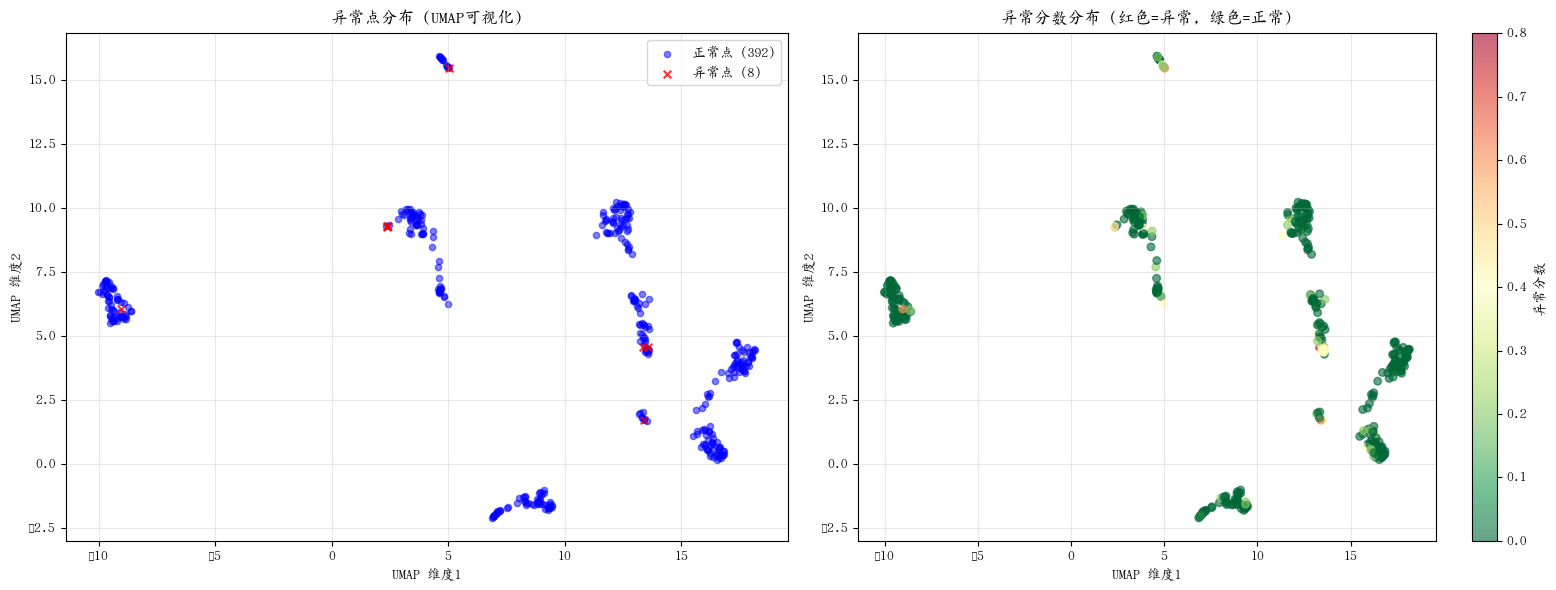

In [21]:
# 使用UMAP降维可视化
print("执行UMAP降维...")
reducer = umap.UMAP(
    n_components=2,
    random_state=42,
    metric='cosine',
    n_neighbors=min(15, len(embeddings_normalized) - 1)
)
embeddings_2d = reducer.fit_transform(embeddings_normalized)
print("✓ UMAP降维完成")

# 可视化异常点分布
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左图: 异常点标记
normal_mask = ~results['combined']['is_outlier']
outlier_mask = results['combined']['is_outlier']

axes[0].scatter(
    embeddings_2d[normal_mask, 0], 
    embeddings_2d[normal_mask, 1],
    c='blue', alpha=0.5, s=20, label=f'正常点 ({np.sum(normal_mask)})'
)
axes[0].scatter(
    embeddings_2d[outlier_mask, 0], 
    embeddings_2d[outlier_mask, 1],
    c='red', alpha=0.8, s=30, marker='x', label=f'异常点 ({np.sum(outlier_mask)})'
)
axes[0].set_title('异常点分布 (UMAP可视化)')
axes[0].set_xlabel('UMAP 维度1')
axes[0].set_ylabel('UMAP 维度2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 右图: 异常分数热图
scatter = axes[1].scatter(
    embeddings_2d[:, 0], 
    embeddings_2d[:, 1],
    c=results['combined']['scores'],
    cmap='RdYlGn_r', s=30, alpha=0.6
)
axes[1].set_title('异常分数分布 (红色=异常, 绿色=正常)')
axes[1].set_xlabel('UMAP 维度1')
axes[1].set_ylabel('UMAP 维度2')
plt.colorbar(scatter, ax=axes[1], label='异常分数')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# 可视化：各方法检测结果对比


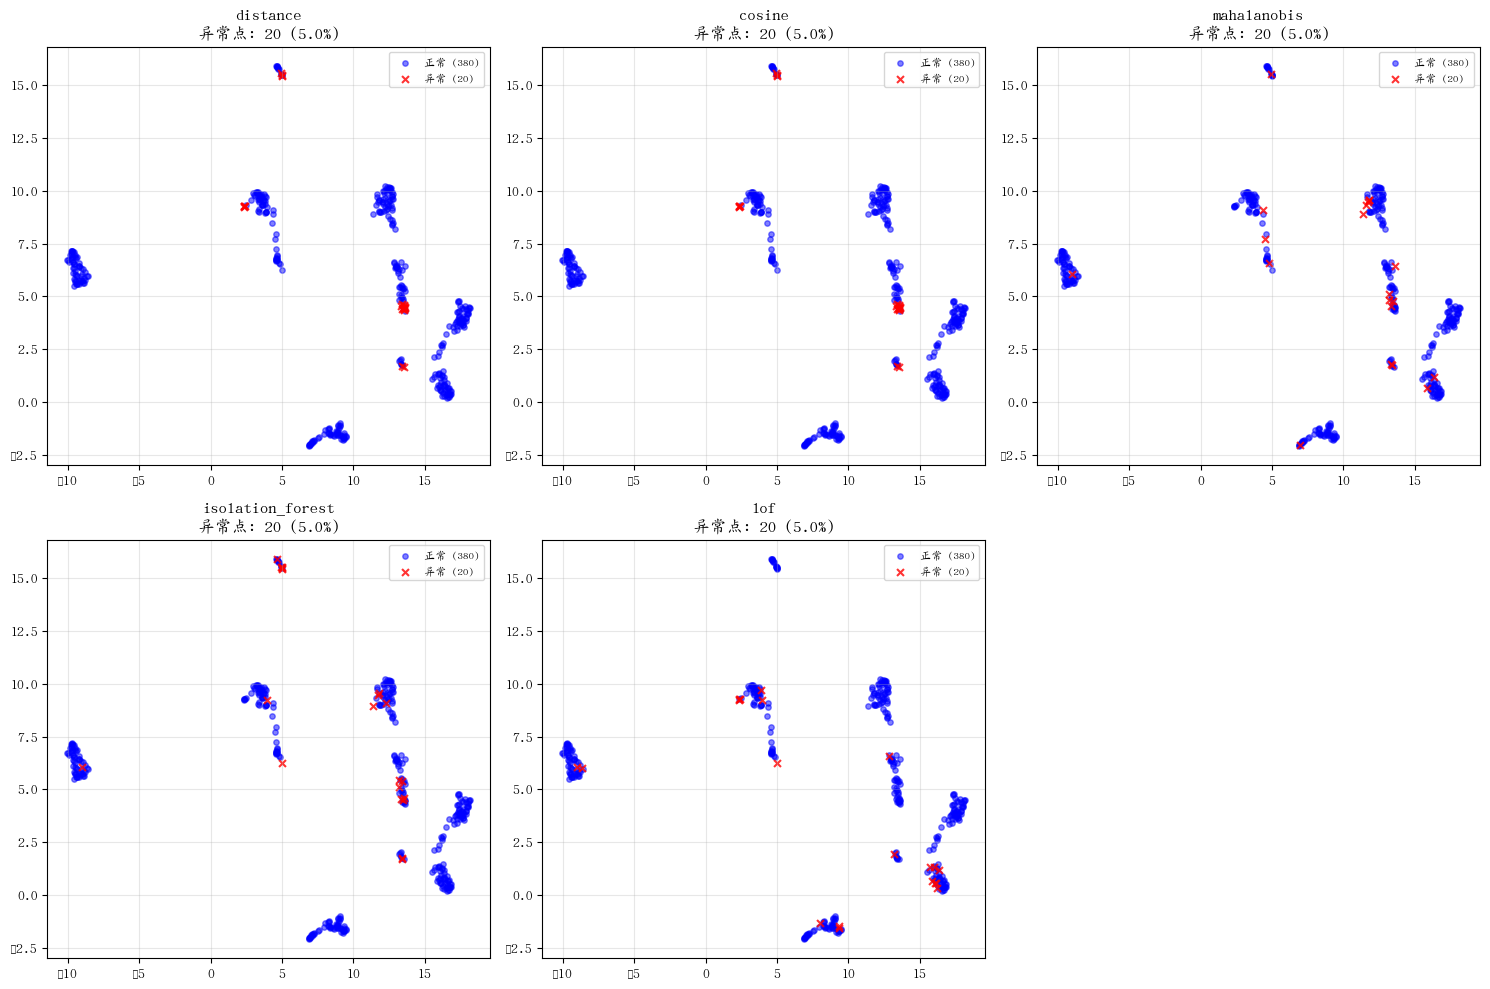

In [22]:
# 可视化各方法的异常点检测结果
n_methods = len(results) - 1  # 排除combined
n_cols = 3
n_rows = (n_methods + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
if n_methods == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for idx, (method_name, result) in enumerate(results.items()):
    if method_name == 'combined' or idx >= len(axes):
        continue
    
    ax = axes[idx]
    normal_mask = ~result['is_outlier']
    outlier_mask = result['is_outlier']
    
    ax.scatter(
        embeddings_2d[normal_mask, 0], 
        embeddings_2d[normal_mask, 1],
        c='blue', alpha=0.5, s=15, label=f'正常 ({np.sum(normal_mask)})'
    )
    ax.scatter(
        embeddings_2d[outlier_mask, 0], 
        embeddings_2d[outlier_mask, 1],
        c='red', alpha=0.8, s=25, marker='x', label=f'异常 ({np.sum(outlier_mask)})'
    )
    ax.set_title(f'{method_name}\n异常点: {np.sum(outlier_mask)} ({np.sum(outlier_mask)/len(embeddings_normalized)*100:.1f}%)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# 隐藏多余的子图
for idx in range(n_methods, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()


# 可视化：异常分数分布


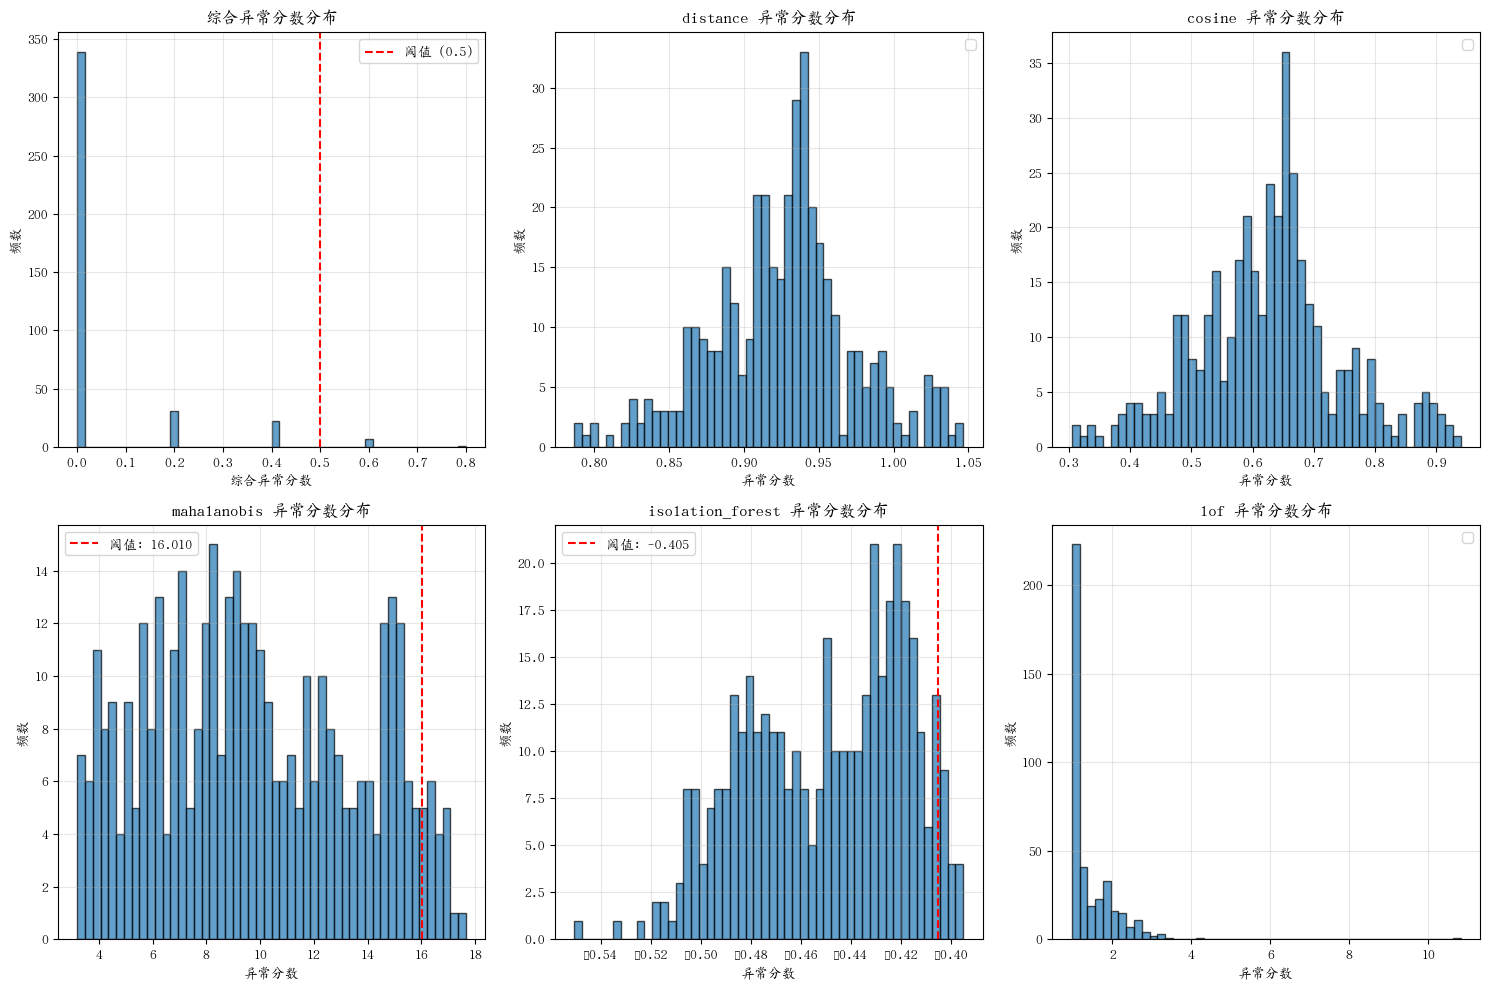

In [23]:
# 可视化异常分数分布
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

plot_idx = 0

# 综合异常分数分布
if 'combined' in results:
    ax = axes[plot_idx]
    ax.hist(results['combined']['scores'], bins=50, alpha=0.7, edgecolor='black')
    ax.axvline(0.5, color='r', linestyle='--', label='阈值 (0.5)')
    ax.set_xlabel('综合异常分数')
    ax.set_ylabel('频数')
    ax.set_title('综合异常分数分布')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plot_idx += 1

# 各方法的异常分数分布
for method_name, result in list(results.items())[:5]:
    if plot_idx >= len(axes):
        break
    if method_name == 'combined':
        continue
    ax = axes[plot_idx]
    scores = result['scores']
    threshold = result['threshold']
    ax.hist(scores, bins=50, alpha=0.7, edgecolor='black')
    if isinstance(threshold, (int, float)):
        ax.axvline(threshold, color='r', linestyle='--', label=f'阈值: {threshold:.3f}')
    ax.set_xlabel('异常分数')
    ax.set_ylabel('频数')
    ax.set_title(f'{method_name} 异常分数分布')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plot_idx += 1

# 隐藏多余的子图
for idx in range(plot_idx, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()
